In [1]:
import numpy
import numpy.core.numeric as numeric_core
import sys
import pandas as pd
import os
import glob
import pickle
import language_tool_python
from tqdm import tqdm
sys.modules['numpy._core.numeric'] = numeric_core

In [2]:
tool = language_tool_python.LanguageTool('en-US')

ModuleNotFoundError: No java install detected. Please install java to use language-tool-python.

In [3]:
xs_path = r'D:\Users\carlos_s\Indiegogo\webrobots\XS02082025.csv'
xs = pd.read_csv(xs_path)

# Set the path to the folder containing the PKL files
folder_path = r'D:\Users\carlos_s\Indiegogo\main_page_scrape'

# Use glob to list all .pkl files in the folder
pkl_files = glob.glob(os.path.join(folder_path, '*.pkl'))

In [4]:
dfs = []

for pkl_file in pkl_files:
    print(f"Loading: {pkl_file}")
    with open(pkl_file, 'rb') as file:
        # Each PKL file is expected to be a DataFrame
        stories = pickle.load(file)
        dfs.append(stories)

# Combine all DataFrames into one
stories = pd.concat(dfs, ignore_index=True)

Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_1.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_10.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_11.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_12.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_13.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_14.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_15.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_16.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_17.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_18.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_2.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_3.pkl
Loading: D:\Users\carlos_s\Indiegogo\main_page_scrape\stories_batch_4.pkl
Loading: D:\Users\carlos_s\In

In [6]:
xs = xs.drop_duplicates(subset='project_id')

stories['word_count'] = stories['story_content'].apply(lambda x: len(str(x).split()))
print(stories[['story_content', 'word_count']].head())

                                       story_content  word_count
0                                                              0
1  Short Summary\n\n\nWe finally found the dream ...         739
2  Dear Friends and Fans,\nI am so excited to sha...         359
3  IT'S TIME TO PLAY: STEP INTO A WORLD OF SOUNDS...         865
4  Summary\n\n\nMirador Television wants to unite...        1173


In [40]:
df_ = stories.drop(columns=['story_content', 'html_content'])


In [43]:
df_.to_csv("text_quality.csv", index=False)

In [8]:
tqdm.pandas()

def grammar_quality(text):
    matches = tool.check(text)
    token_count = len(str(text).split())
    if token_count > 0:
        return 1 - (len(matches) / token_count)
    return None

# Use progress_apply instead of apply to show the progress bar
stories['text_quality'] = stories['story_content'].progress_apply(grammar_quality)
stories[['story_content', 'text_quality']].head()

100%|██████████████████████████████████████████████████████████████████████████| 17257/17257 [2:30:24<00:00,  1.91it/s]


,story_content,text_quality
0,,NaN
1,Short Summary\n\n\nWe finally found the dream ...,0.982409
2,"Dear Friends and Fans,\nI am so excited to sha...",0.988858
3,IT'S TIME TO PLAY: STEP INTO A WORLD OF SOUNDS...,0.959538
4,Summary\n\n\nMirador Television wants to unite...,0.972720


In [9]:
stories.head()

,id,story_content,html_content,word_count,text_quality
0,2684556,,"<html lang=""en""><head><meta http-equiv=""origin...",0,NaN
1,2726165,Short Summary\n\n\nWe finally found the dream ...,"<html lang=""en""><head><meta http-equiv=""origin...",739,0.982409
2,2821770,"Dear Friends and Fans,\nI am so excited to sha...","<html lang=""en""><head><meta http-equiv=""origin...",359,0.988858
3,2822666,IT'S TIME TO PLAY: STEP INTO A WORLD OF SOUNDS...,"<html lang=""en""><head><meta http-equiv=""origin...",865,0.959538
4,2646452,Summary\n\n\nMirador Television wants to unite...,"<html lang=""en""><head><meta http-equiv=""origin...",1173,0.972720


In [10]:
#### Merge xs with stories ####
df = stories.merge(xs, left_on='id', right_on='project_id', how='left')
print(df.head())


        id                                      story_content  \
0  2684556                                                      
1  2726165  Short Summary\n\n\nWe finally found the dream ...   
2  2821770  Dear Friends and Fans,\nI am so excited to sha...   
3  2822666  IT'S TIME TO PLAY: STEP INTO A WORLD OF SOUNDS...   
4  2646452  Summary\n\n\nMirador Television wants to unite...   

                                        html_content  word_count  \
0  <html lang="en"><head><meta http-equiv="origin...           0   
1  <html lang="en"><head><meta http-equiv="origin...         739   
2  <html lang="en"><head><meta http-equiv="origin...         359   
3  <html lang="en"><head><meta http-equiv="origin...         865   
4  <html lang="en"><head><meta http-equiv="origin...        1173   

   text_quality  bullet_point               category  \
0           NaN           NaN           Productivity   
1      0.982409           NaN       Local Businesses   
2      0.988858           NaN   

In [23]:
df['goal_reached'] = (df['funds_raised_percent'] >= 100).astype(int)
# Ensure 'open_date' is in datetime format with utc=True
df['open_date'] = pd.to_datetime(df['open_date'], utc=True)

In [35]:

# Group by month and compute the average word_count. 'M' indicates monthly frequency.
monthly_avg = df.groupby(pd.Grouper(key='open_date', freq='M'))['text_quality'].mean()


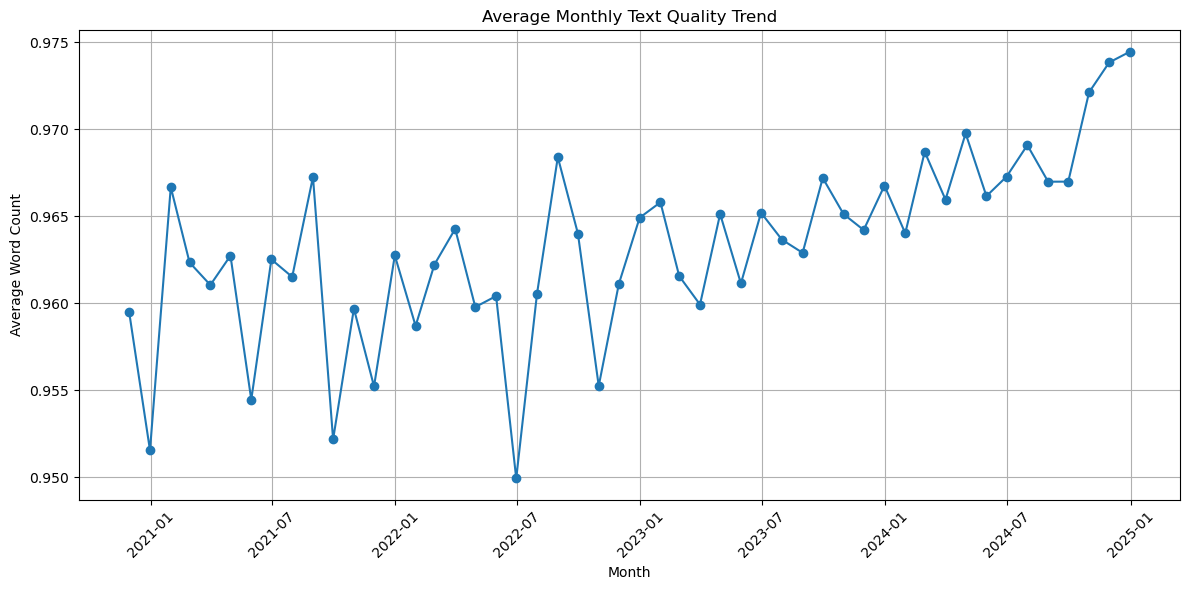

In [36]:

import matplotlib.pyplot as plt

# Plot the trend line
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-')
plt.title('Average Monthly Text Quality Trend')
plt.xlabel('Month')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
#### Goal Reached line ###

# Group by month and goal_reached, then compute the average tl_quality
monthly_avg_goal_reached = df[df['goal_reached'] == 1].groupby(pd.Grouper(key='open_date', freq='M'))['text_quality'].mean()
monthly_avg_not_reached = df[df['goal_reached'] == 0].groupby(pd.Grouper(key='open_date', freq='M'))['text_quality'].mean()


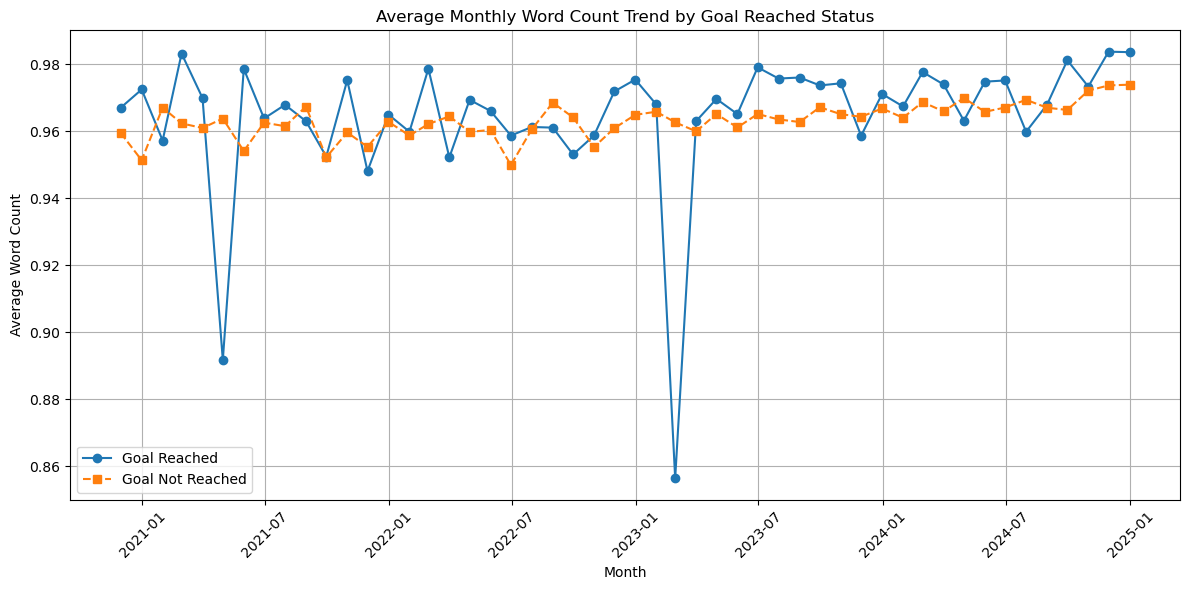

In [28]:



# Plot the trend lines
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_goal_reached.index, monthly_avg_goal_reached.values, marker='o', linestyle='-', label='Goal Reached')
plt.plot(monthly_avg_not_reached.index, monthly_avg_not_reached.values, marker='s', linestyle='--', label='Goal Not Reached')

# Formatting
plt.title('Average Monthly Word Count Trend by Goal Reached Status')
plt.xlabel('Month')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()  # Add legend
plt.grid(True)
plt.tight_layout()
plt.show()

